Naive runtime: 0.001369 seconds
Vectorized runtime: 0.001331 seconds

NAIVE RESULTS
Cash: $10,434.87
Quantity: 0
Holding: $0.00
Total: $10,434.87

VECTORIZED RESULTS
Cash: $10,434.87
Quantity: 0.0
Holding: $0.00
Total: $10,434.87

RESULT VALIDATION
Cash equal: True
Holding equal: True
Total equal: True


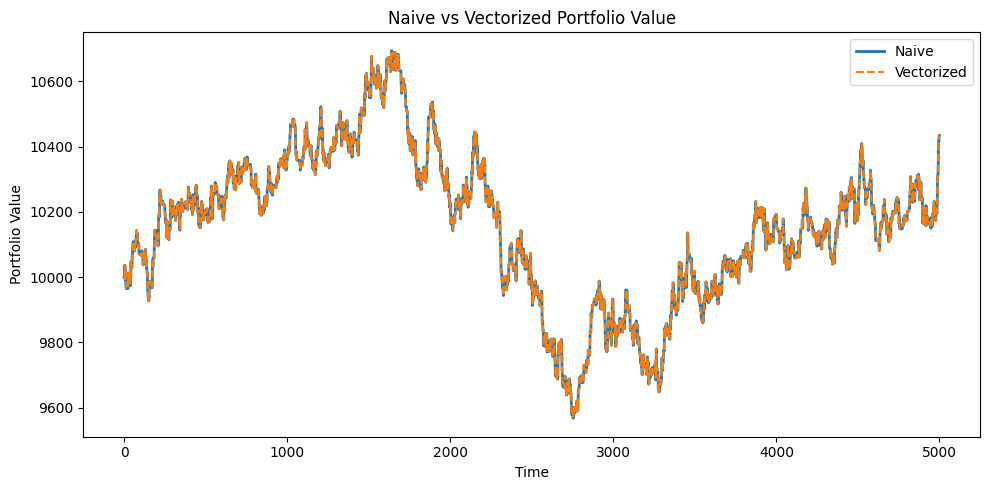

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time


# 🟥 NAIVE BACKTESTER
def naive_backtester_engine(prices, signals, initial_cash=10000, qty=20):

    n = len(prices)
    cash = initial_cash
    position = 0

    cash_series = []
    holding_series = []
    total_series = []

    start = time.perf_counter()

    for i, (price, sig) in enumerate(zip(prices, signals)):

        if sig == "BUY" and position == 0:
            position = qty
            cash -= qty * price

        elif sig == "SELL" and position == qty:
            cash += qty * price
            position = 0

        # Force exit on last day
        if i == n - 1 and position == qty:
            cash += qty * price
            position = 0

        holding_value = position * price
        total = cash + holding_value

        cash_series.append(cash)
        holding_series.append(holding_value)
        total_series.append(total)

    runtime = time.perf_counter() - start

    df = pd.DataFrame({
        "Price": prices,
        "Signal": signals,
        "Cash": cash_series,
        "Holding": holding_series,
        "Total": total_series
    })

    final_cash = cash
    final_quantity = position
    final_holding = holding_series[-1]
    final_total = total_series[-1]

    return df, runtime, final_cash, final_quantity, final_holding, final_total


# 🟩 VECTORIZED BACKTESTER
def vectorized_backtester_engine(prices, signals, initial_cash=10000, qty=20):

    start = time.perf_counter()

    price = pd.Series(prices)
    signal = pd.Series(signals)

    target = pd.Series(np.nan, index=price.index)
    target[signal == "BUY"] = qty
    target[signal == "SELL"] = 0

    position = target.ffill().fillna(0)

    # Force exit on last day
    position.iloc[-1] = 0

    trade = position.diff().fillna(position)

    cashflow = -trade * price
    cash = initial_cash + cashflow.cumsum()

    holding = position * price
    total = cash + holding

    runtime = time.perf_counter() - start

    df = pd.DataFrame({
        "Price": price,
        "Signal": signal,
        "Cash": cash,
        "Holding": holding,
        "Total": total
    })

    final_cash = cash.iloc[-1]
    final_quantity = position.iloc[-1]
    final_holding = holding.iloc[-1]
    final_total = total.iloc[-1]

    return df, runtime, final_cash, final_quantity, final_holding, final_total


# 🟦 STEP 1 — Generate price series
np.random.seed(32500)
n = 5000
prices = np.cumsum(np.random.randn(n)) + 100


# 🟩 STEP 2 — Generate signals
signals = np.random.choice(["BUY", "SELL", "HOLD"], size=n)


# 🟧 STEP 3 — Run both engines
df_naive, runtime_naive, cash_n, qty_n, hold_n, total_n = naive_backtester_engine(prices, signals)

df_vec, runtime_vec, cash_v, qty_v, hold_v, total_v = vectorized_backtester_engine(prices, signals)


# 🟨 STEP 4 — Print runtime comparison
print(f"Naive runtime: {runtime_naive:.6f} seconds")
print(f"Vectorized runtime: {runtime_vec:.6f} seconds")


# 🟩 STEP 5 — Print final portfolio values
fmt = lambda x: f"${x:,.2f}"

print("\nNAIVE RESULTS")
print("Cash:", fmt(cash_n))
print("Quantity:", qty_n)
print("Holding:", fmt(hold_n))
print("Total:", fmt(total_n))

print("\nVECTORIZED RESULTS")
print("Cash:", fmt(cash_v))
print("Quantity:", qty_v)
print("Holding:", fmt(hold_v))
print("Total:", fmt(total_v))


# 🟪 STEP 6 — Verify results match
print("\nRESULT VALIDATION")

print("Cash equal:", np.isclose(cash_n, cash_v))
print("Holding equal:", np.isclose(hold_n, hold_v))
print("Total equal:", np.isclose(total_n, total_v))


# 🟫 STEP 7 — Plot comparison
plt.figure(figsize=(10,5))

plt.plot(df_naive["Total"], label="Naive", linewidth=2)
plt.plot(df_vec["Total"], label="Vectorized", linestyle="--")

plt.title("Naive vs Vectorized Portfolio Value")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.legend()
plt.tight_layout()
plt.show()